# Logistic Regression Classification

This notebook investigates the use of Logistic Regression for predictive maintenance classification.

The experiments focus on:

- classifier performance

- class imbalance behaviour

- model generalisation

- comparison with Decision Tree classification

- evaluation using multiple classification metrics

## Imports 

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Machine Learning Imports

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Dataset

In [20]:
df = pd.read_csv('../data/predictive_maintenance.csv')

# Dataset Preprocessing

The dataset was preprocessed before model training.

The preprocessing steps included:

- removal of identifiers
- removal of leakage features
- one-hot encoding of categorical variables
- feature scaling

In [4]:
df_clean = df.drop(columns=['UDI', 'Product ID', 'Failure Type'])

df_clean = pd.get_dummies(df_clean, columns=['Type'])

df_clean = df_clean.astype(int, errors='ignore')

df_clean.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_H,Type_L,Type_M
0,298,308,1551,42,0,0,0,0,1
1,298,308,1408,46,3,0,0,1,0
2,298,308,1498,49,5,0,0,1,0
3,298,308,1433,39,7,0,0,1,0
4,298,308,1408,40,9,0,0,1,0


## Feature and Target Selection

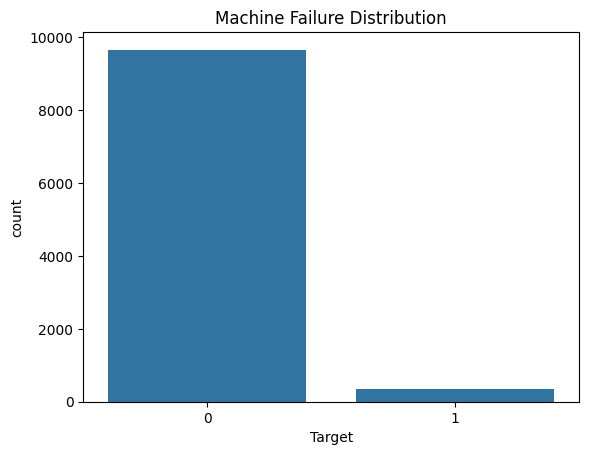

In [5]:
sns.countplot(x='Target', data=df)

plt.title('Machine Failure Distribution')

plt.show()

In [6]:
X = df_clean.drop('Target', axis=1)

y = df_clean['Target']

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

Logistic Regression is sensitive to differences in feature scale.

Standardisation was therefore applied so that features had:

- mean approximately equal to 0
- standard deviation approximately equal to 1

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Baseline Logistic Regression Model

## Model Training 

In [9]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Make Predictions 

In [10]:
y_pred = lr_model.predict(X_test_scaled)

## Evaluate Model 

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.9675

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.62      0.12      0.20        68

    accuracy                           0.97      2000
   macro avg       0.79      0.56      0.59      2000
weighted avg       0.96      0.97      0.96      2000



## Confusion Matrix 

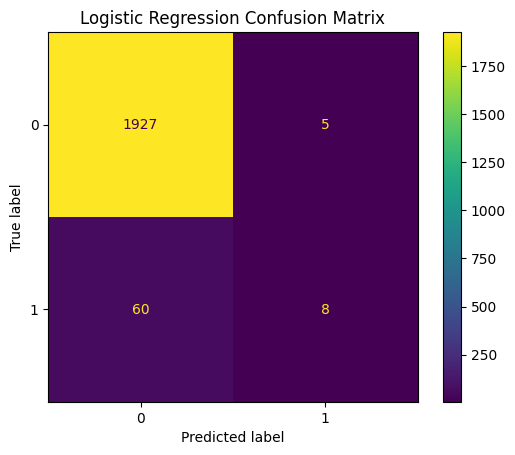

In [12]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title('Logistic Regression Confusion Matrix')

plt.show()

## Logistic Regression Evaluation

The Logistic Regression classifier achieved an overall accuracy of 96.75%. However, the classifier performed poorly when identifying machine failures.

The model achieved a recall score of only 0.12 for the failure class, meaning that approximately 88% of machine failures were missed.

This demonstrates the limitations of relying solely on accuracy when evaluating highly imbalanced datasets. Despite achieving high overall accuracy, the classifier failed to effectively identify the minority failure class.

Compared to the Decision Tree classifier, Logistic Regression showed significantly weaker performance for predictive maintenance classification. This suggests that the relationship between the input features and machine failures may be non-linear and therefore more effectively captured by Decision Tree-based approaches.

# Class Imbalance Mitigation

Additional experiments were performed using balanced class weighting to investigate whether Logistic Regression recall performance could be improved for the minority failure class.

In [13]:
balanced_lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

balanced_lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [14]:
balanced_pred = balanced_lr.predict(X_test_scaled)

In [15]:
print("Accuracy:", accuracy_score(y_test, balanced_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, balanced_pred))

Accuracy: 0.83

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.15      0.85      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.84      0.58      2000
weighted avg       0.97      0.83      0.88      2000



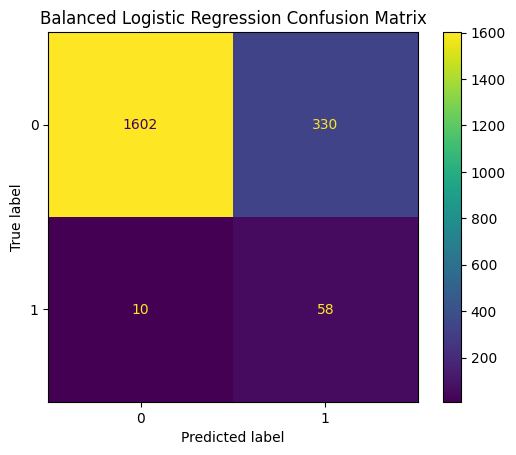

In [16]:
cm = confusion_matrix(y_test, balanced_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title('Balanced Logistic Regression Confusion Matrix')

plt.show()

## Balanced Logistic Regression Analysis

Applying balanced class weighting significantly improved the Logistic Regression classifier's ability to detect machine failures.

Recall for the failure class increased from 0.12 to 0.85, reducing the number of missed failures from 60 to only 10 observations.

However, this improvement came at the cost of substantially increased false positives, rising from 5 to 330 cases. This demonstrates the precision-recall tradeoff commonly encountered in highly imbalanced classification problems.

In a real predictive maintenance environment, the preferred balance between recall and precision would depend on operational requirements and the relative costs of missed failures versus unnecessary maintenance interventions.